In [1]:
print("I am building a T9-level research project")

I am building a T9-level research project


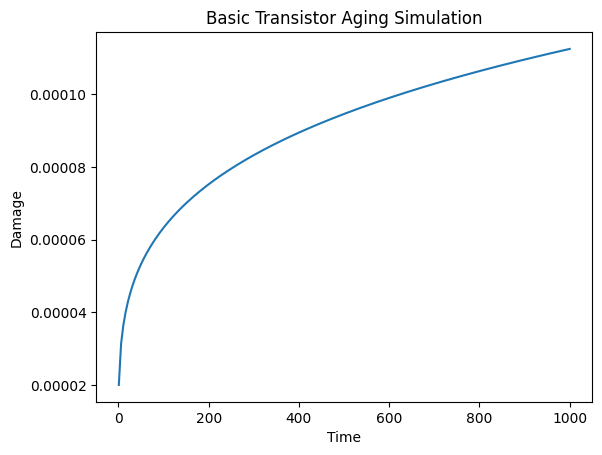

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Create time axis
time = np.linspace(1, 1000, 200)

# Basic aging formula
A = 0.00002
n = 0.25

damage = A * (time ** n)

plt.plot(time, damage)
plt.xlabel("Time")
plt.ylabel("Damage")
plt.title("Basic Transistor Aging Simulation")
plt.show()

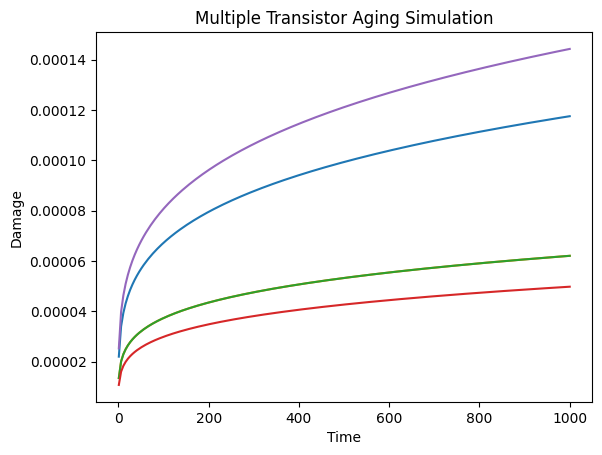

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation parameters
num_transistors = 100
time = np.linspace(1, 1000, 200)

all_damage = []

for i in range(num_transistors):
    A = np.random.uniform(0.00001, 0.00003)   # random aging factor
    n = np.random.uniform(0.2, 0.3)           # random exponent

    damage = A * (time ** n)
    all_damage.append(damage)

all_damage = np.array(all_damage)

# Plot 5 random transistor aging curves
for i in np.random.choice(num_transistors, 5):
    plt.plot(time, all_damage[i])

plt.xlabel("Time")
plt.ylabel("Damage")
plt.title("Multiple Transistor Aging Simulation")
plt.show()

In [4]:
failure_threshold = 0.00012

failure_times = []

for i in range(num_transistors):
    damage_curve = all_damage[i]

    # Find first time where damage exceeds threshold
    fail_indices = np.where(damage_curve >= failure_threshold)[0]

    if len(fail_indices) > 0:
        fail_time = time[fail_indices[0]]
    else:
        fail_time = None  # did not fail in simulation window

    failure_times.append(fail_time)

# Print first 10 failure times
print("First 10 Failure Times:")
print(failure_times[:10])

First 10 Failure Times:
[None, np.float64(136.5427135678392), np.float64(362.4472361809045), None, None, None, None, None, np.float64(292.1658291457286), None]


In [5]:
import pandas as pd

clean_times = []
event_flags = []

for t in failure_times:
    if t is None:
        clean_times.append(time[-1])  # max simulation time
        event_flags.append(0)         # did not fail
    else:
        clean_times.append(float(t))
        event_flags.append(1)

# Create DataFrame
dataset = pd.DataFrame({
    "time_to_failure": clean_times,
    "failed": event_flags
})

print(dataset.head(10))

   time_to_failure  failed
0      1000.000000       0
1       136.542714       1
2       362.447236       1
3      1000.000000       0
4      1000.000000       0
5      1000.000000       0
6      1000.000000       0
7      1000.000000       0
8       292.165829       1
9      1000.000000       0


In [6]:
import numpy as np
import pandas as pd

# Simulation parameters
num_transistors = 500
time = np.linspace(1, 1000, 200)
failure_threshold = 0.00012

data_records = []

for i in range(num_transistors):

    # Random physical parameters
    A = np.random.uniform(0.00001, 0.00003)
    n = np.random.uniform(0.2, 0.3)
    temperature = np.random.uniform(300, 380)  # Kelvin
    stress = np.random.uniform(0.8, 1.2)       # normalized stress

    # Aging model (temperature affects speed)
    damage = A * (time ** n) * (temperature / 300) * stress

    # Find failure time
    fail_indices = np.where(damage >= failure_threshold)[0]

    if len(fail_indices) > 0:
        fail_time = time[fail_indices[0]]
        failed = 1
    else:
        fail_time = time[-1]
        failed = 0

    # Store everything
    data_records.append([A, n, temperature, stress, fail_time, failed])

# Create dataset
dataset = pd.DataFrame(data_records, columns=[
    "A", "n", "temperature", "stress",
    "time_to_failure", "failed"
])

print(dataset.head())
print("\nTotal failed:", dataset["failed"].sum())

          A         n  temperature    stress  time_to_failure  failed
0  0.000026  0.207502   313.076544  1.028589      1000.000000       0
1  0.000019  0.261367   348.506226  1.117569       472.889447       1
2  0.000014  0.257192   309.457381  0.933121      1000.000000       0
3  0.000022  0.294931   316.834614  1.022225       252.005025       1
4  0.000024  0.292532   324.077556  1.068410       156.623116       1

Total failed: 256


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Features and target
X = dataset[["A", "n", "temperature", "stress"]]
y = dataset["time_to_failure"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, predictions)
print("Mean Absolute Error:", mae)


Mean Absolute Error: 61.47615075376886


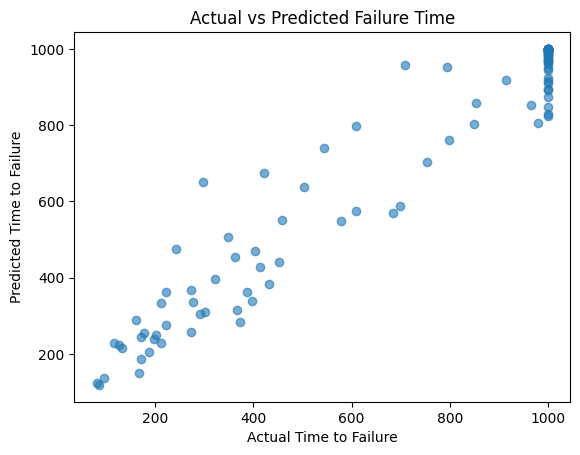

In [8]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions, alpha=0.6)
plt.xlabel("Actual Time to Failure")
plt.ylabel("Predicted Time to Failure")
plt.title("Actual vs Predicted Failure Time")
plt.show()

In [9]:
import numpy as np

mean_prediction = np.mean(y_train)
baseline_predictions = np.full_like(y_test, mean_prediction)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
print("Baseline MAE (mean predictor):", baseline_mae)

Baseline MAE (mean predictor): 322.33362512562815


In [10]:
import pandas as pd

importances = model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

       Feature  Importance
0            A    0.565351
1            n    0.278667
3       stress    0.102416
2  temperature    0.053566


In [11]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.0/350.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.1 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=25ef8be09b89a67c12cbe040ad1275580e5a290266440406379318d6e9c49877
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [12]:
from lifelines import CoxPHFitter

# Prepare survival dataset
survival_data = dataset.copy()

# Fit Cox model
cph = CoxPHFitter()
cph.fit(survival_data, duration_col="time_to_failure", event_col="failed")

# Print summary
cph.print_summary()

/usr/local/lib/python3.12/dist-packages/lifelines/utils/__init__.py:1100: ConvergenceWarning: Column(s) ['A'] have very low variance. This may harm convergence. 1) Are you using formula's? Did you mean to add '-1' to the end. 2) Try dropping this redundant column before fitting if convergence fails.

  warnings.warn(dedent(warning_text), ConvergenceWarning)


<lifelines.CoxPHFitter: fitted with 500 total observations, 244 right-censored observations>
             duration col = 'time_to_failure'
                event col = 'failed'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 256
   partial log-likelihood = -767.01
         time fit was run = 2026-03-01 06:26:16 UTC

---
                  coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                         
A           1604844.33       inf  75534.61      1456799.22      1752889.45                 NaN                 inf
n               194.81  4.04e+84      9.02          177.14          212.48            8.56e+76            1.90e+92
temperature       0.10      1.10      0.01            0.09            0.11                1.09                1.11
stress           34.87  1.40e+15      1.76           31.43           38.32            4.48e+13            4.37e+16

             cmp to     z      p  -log2(p)
covariate                                 
A              0.00 21.25 <0.005    330.36
n              0.00 21.61 <0.005    341.61
temperature    0.00 18.99 <0.005    264.73
stress         0.00 19.86 <0.005    289.27
---
Concordance = 0.98
Partial AIC = 1542.03
log-likelihood ratio test = 1486.68 on 4 df
-log2(p) of ll-ratio test = inf

In [13]:
from sklearn.preprocessing import StandardScaler

# Copy dataset
scaled_data = dataset.copy()

# Scale only features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    scaled_data[["A", "n", "temperature", "stress"]]
)

scaled_data[["A", "n", "temperature", "stress"]] = scaled_features

# Fit Cox again
cph_scaled = CoxPHFitter()
cph_scaled.fit(scaled_data, duration_col="time_to_failure", event_col="failed")

cph_scaled.print_summary()

<lifelines.CoxPHFitter: fitted with 500 total observations, 244 right-censored observations>
             duration col = 'time_to_failure'
                event col = 'failed'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 256
   partial log-likelihood = -767.01
         time fit was run = 2026-03-01 06:28:07 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
A            9.07   8671.36      0.43            8.23            9.90             3756.67            20015.73
n            5.57    263.02      0.26            5.07            6.08              158.67              435.99
temperature  2.26      9.55      0.12            2.02            2.49                7.56               12.05
stress       3.95     51.72      0.20            3.56            4.34               35.04               76.34

             cmp to     z      p  -log2(p)
covariate                                 
A              0.00 21.25 <0.005    330.36
n              0.00 21.61 <0.005    341.61
temperature    0.00 18.99 <0.005    264.73
stress         0.00 19.86 <0.005    289.27
---
Concordance = 0.98
Partial AIC = 1542.03
log-likelihood ratio test = 1486.68 on 4 df
-log2(p) of ll-ratio test = inf

In [14]:
import networkx as nx
import random

num_nodes = len(dataset)

# Create graph
G = nx.Graph()

# Add nodes
G.add_nodes_from(range(num_nodes))

# Randomly connect nodes
for node in G.nodes():
    neighbors = random.sample(range(num_nodes), 4)
    for n in neighbors:
        if n != node:
            G.add_edge(node, n)

print("Total Nodes:", G.number_of_nodes())
print("Total Edges:", G.number_of_edges())


Total Nodes: 500
Total Edges: 1991


In [15]:
import numpy as np

neighbor_temp = []
neighbor_stress = []

for node in G.nodes():
    neighbors = list(G.neighbors(node))

    if len(neighbors) > 0:
        avg_temp = dataset.loc[neighbors, "temperature"].mean()
        avg_stress = dataset.loc[neighbors, "stress"].mean()
    else:
        avg_temp = dataset.loc[node, "temperature"]
        avg_stress = dataset.loc[node, "stress"]

    neighbor_temp.append(avg_temp)
    neighbor_stress.append(avg_stress)

dataset["neighbor_temp"] = neighbor_temp
dataset["neighbor_stress"] = neighbor_stress

dataset.head()

,A,n,temperature,stress,time_to_failure,failed,neighbor_temp,neighbor_stress
0,0.000026,0.207502,313.076544,1.028589,1000.000000,0,341.589212,1.028546
1,0.000019,0.261367,348.506226,1.117569,472.889447,1,345.767921,0.985375
2,0.000014,0.257192,309.457381,0.933121,1000.000000,0,336.621028,0.930050
3,0.000022,0.294931,316.834614,1.022225,252.005025,1,342.928007,1.044442
4,0.000024,0.292532,324.077556,1.068410,156.623116,1,345.180492,1.083485


In [16]:
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter

# Copy dataset
graph_data = dataset.copy()

# Scale all numeric features except survival columns
scaler = StandardScaler()
features_to_scale = [
    "A", "n", "temperature", "stress",
    "neighbor_temp", "neighbor_stress"
]

graph_data[features_to_scale] = scaler.fit_transform(
    graph_data[features_to_scale]
)

# Fit Cox model
cph_graph = CoxPHFitter()
cph_graph.fit(graph_data,
              duration_col="time_to_failure",
              event_col="failed")

cph_graph.print_summary()

<lifelines.CoxPHFitter: fitted with 500 total observations, 244 right-censored observations>
             duration col = 'time_to_failure'
                event col = 'failed'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 256
   partial log-likelihood = -766.37
         time fit was run = 2026-03-01 06:31:55 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
A                9.11   9049.02      0.43            8.27            9.96             3886.81            21067.37
n                5.59    268.33      0.26            5.08            6.10              161.22              446.61
temperature      2.27      9.69      0.12            2.04            2.51                7.65               12.26
stress           3.95     52.16      0.20            3.56            4.34               35.29               77.08
neighbor_temp   -0.02      0.98      0.07           -0.16            0.12                0.85                1.13
neighbor_stress  0.08      1.08      0.07           -0.06            0.22                0.94                1.25

                 cmp to     z      p  -log2(p)
covariate                                     
A                  0.00 21.13 <0.005    326.79
n                  0.00 21.51 <0.005    338.63
temperature        0.00 18.89 <0.005    261.97
stress             0.00 19.84 <0.005    288.65
neighbor_temp      0.00 -0.27   0.79      0.34
neighbor_stress    0.00  1.08   0.28      1.84
---
Concordance = 0.98
Partial AIC = 1544.75
log-likelihood ratio test = 1487.96 on 6 df
-log2(p) of ll-ratio test = inf

In [17]:
import numpy as np
import pandas as pd
import networkx as nx
import random

num_transistors = 500
time = np.linspace(1, 1000, 200)
failure_threshold = 0.00012

alpha = 0.3   # temperature coupling
beta = 0.3    # stress coupling

# Create graph
G = nx.Graph()
G.add_nodes_from(range(num_transistors))

for node in G.nodes():
    neighbors = random.sample(range(num_transistors), 4)
    for n in neighbors:
        if n != node:
            G.add_edge(node, n)

# Initialize base parameters
A_vals = np.random.uniform(0.00001, 0.00003, num_transistors)
n_vals = np.random.uniform(0.2, 0.3, num_transistors)
temp_vals = np.random.uniform(300, 380, num_transistors)
stress_vals = np.random.uniform(0.8, 1.2, num_transistors)

data_records = []

for i in range(num_transistors):

    neighbors = list(G.neighbors(i))

    if len(neighbors) > 0:
        neighbor_temp = np.mean(temp_vals[neighbors])
        neighbor_stress = np.mean(stress_vals[neighbors])
    else:
        neighbor_temp = temp_vals[i]
        neighbor_stress = stress_vals[i]

    effective_temp = temp_vals[i] + alpha * neighbor_temp
    effective_stress = stress_vals[i] + beta * neighbor_stress

    damage = A_vals[i] * (time ** n_vals[i]) * (effective_temp / 300) * effective_stress

    fail_indices = np.where(damage >= failure_threshold)[0]

    if len(fail_indices) > 0:
        fail_time = time[fail_indices[0]]
        failed = 1
    else:
        fail_time = time[-1]
        failed = 0

    data_records.append([
        A_vals[i],
        n_vals[i],
        temp_vals[i],
        stress_vals[i],
        neighbor_temp,
        neighbor_stress,
        fail_time,
        failed
    ])

dataset_spatial = pd.DataFrame(data_records, columns=[
    "A", "n", "temperature", "stress",
    "neighbor_temp", "neighbor_stress",
    "time_to_failure", "failed"
])

print(dataset_spatial.head())
print("Total failed:", dataset_spatial["failed"].sum())

          A         n  temperature    stress  neighbor_temp  neighbor_stress  \
0  0.000018  0.272482   322.697816  1.103473     343.882504         1.002903   
1  0.000029  0.215283   361.171112  1.151426     358.189148         1.038975   
2  0.000025  0.215627   308.337573  1.040714     351.156232         0.930737   
3  0.000012  0.270535   366.123988  1.070180     341.186420         1.010439   
4  0.000019  0.251576   321.665070  1.052584     337.811607         0.943827   

   time_to_failure  failed  
0        81.321608       1  
1        16.060302       1  
2        86.341709       1  
3       297.185930       1  
4       121.482412       1  
Total failed: 459


In [18]:
from sklearn.preprocessing import StandardScaler
from lifelines import CoxPHFitter

# Copy dataset
data_no_graph = dataset_spatial.copy()

# Scale only base features
scaler = StandardScaler()
base_features = ["A", "n", "temperature", "stress"]

data_no_graph[base_features] = scaler.fit_transform(
    data_no_graph[base_features]
)

# Fit Cox model
cph_no_graph = CoxPHFitter()
cph_no_graph.fit(data_no_graph[base_features + ["time_to_failure", "failed"]],
                 duration_col="time_to_failure",
                 event_col="failed")

cph_no_graph.print_summary()

<lifelines.CoxPHFitter: fitted with 500 total observations, 41 right-censored observations>
             duration col = 'time_to_failure'
                event col = 'failed'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 459
   partial log-likelihood = -1470.62
         time fit was run = 2026-03-01 06:34:04 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
A            8.19   3598.54      0.28            7.63            8.74             2067.19             6264.30
n            3.65     38.30      0.13            3.38            3.91               29.50               49.72
temperature  1.50      4.47      0.07            1.36            1.64                3.89                5.15
stress       2.55     12.77      0.10            2.35            2.75               10.48               15.57

             cmp to     z      p  -log2(p)
covariate                                 
A              0.00 28.95 <0.005    609.79
n              0.00 27.36 <0.005    545.17
temperature    0.00 20.89 <0.005    319.61
stress         0.00 25.24 <0.005    464.39
---
Concordance = 0.98
Partial AIC = 2949.25
log-likelihood ratio test = 2053.35 on 4 df
-log2(p) of ll-ratio test = inf

In [19]:
# Copy dataset
data_with_graph = dataset_spatial.copy()

# Scale all features
scaler = StandardScaler()
all_features = [
    "A", "n", "temperature", "stress",
    "neighbor_temp", "neighbor_stress"
]

data_with_graph[all_features] = scaler.fit_transform(
    data_with_graph[all_features]
)

# Fit Cox model
cph_with_graph = CoxPHFitter()
cph_with_graph.fit(data_with_graph[all_features + ["time_to_failure", "failed"]],
                   duration_col="time_to_failure",
                   event_col="failed")

cph_with_graph.print_summary()

<lifelines.CoxPHFitter: fitted with 500 total observations, 41 right-censored observations>
             duration col = 'time_to_failure'
                event col = 'failed'
      baseline estimation = breslow
   number of observations = 500
number of events observed = 459
   partial log-likelihood = -1450.09
         time fit was run = 2026-03-01 06:34:45 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
A                8.57   5245.18      0.30            7.98            9.15             2933.79             9377.58
n                3.85     47.17      0.14            3.58            4.13               35.77               62.20
temperature      1.55      4.72      0.07            1.41            1.70                4.09                5.45
stress           2.66     14.23      0.11            2.45            2.86               11.58               17.48
neighbor_temp    0.12      1.13      0.05            0.03            0.22                1.03                1.24
neighbor_stress  0.32      1.38      0.05            0.22            0.43                1.24                1.54

                 cmp to     z      p  -log2(p)
covariate                                     
A                  0.00 28.89 <0.005    607.36
n                  0.00 27.31 <0.005    543.21
temperature        0.00 21.12 <0.005    326.53
stress             0.00 25.26 <0.005    465.08
neighbor_temp      0.00  2.59   0.01      6.72
neighbor_stress    0.00  6.03 <0.005     29.15
---
Concordance = 0.98
Partial AIC = 2912.18
log-likelihood ratio test = 2094.41 on 6 df
-log2(p) of ll-ratio test = inf

In [20]:
!pip install torch

In [24]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.preprocessing import StandardScaler

# Use spatial dataset
data_nn = dataset_spatial.copy()

features = [
    "A", "n", "temperature", "stress",
    "neighbor_temp", "neighbor_stress"
]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_nn[features])

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
time_tensor = torch.tensor(data_nn["time_to_failure"].values, dtype=torch.float32)
event_tensor = torch.tensor(data_nn["failed"].values, dtype=torch.float32)

class DeepSurv(nn.Module):
    def __init__(self, input_dim):
        super(DeepSurv, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = DeepSurv(X_tensor.shape[1])

def cox_loss(risk_scores, times, events):
    # Sort by descending time
    order = torch.argsort(times, descending=True)
    risk_scores = risk_scores[order]
    events = events[order]

    log_cumsum = torch.logcumsumexp(risk_scores, dim=0)
    likelihood = risk_scores - log_cumsum
    loss = -torch.sum(likelihood * events) / torch.sum(events)
    return loss

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    risk_scores = model(X_tensor).squeeze()
    loss = cox_loss(risk_scores, time_tensor, event_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")


        from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    risk_scores = model(X_tensor).squeeze().numpy()

c_index = concordance_index(
    data_nn["time_to_failure"],
    -risk_scores,
    data_nn["failed"]
)

print("DeepSurv Concordance:", c_index)

NameError: name 'optimizer' is not defined

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [26]:
for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    risk_scores = model(X_tensor).squeeze()
    loss = cox_loss(risk_scores, time_tensor, event_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 5.4287
Epoch 50, Loss: 2.2977
Epoch 100, Loss: 1.9293
Epoch 150, Loss: 1.7679


In [27]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    risk_scores = model(X_tensor).squeeze().numpy()

c_index = concordance_index(
    data_nn["time_to_failure"],
    -risk_scores,
    data_nn["failed"]
)

print("DeepSurv Concordance:", c_index)

DeepSurv Concordance: 0.9989653133622388


In [28]:
from sklearn.model_selection import train_test_split

# Split indices
train_idx, test_idx = train_test_split(
    np.arange(len(data_nn)),
    test_size=0.3,
    random_state=42
)

X_train = X_tensor[train_idx]
X_test = X_tensor[test_idx]

time_train = time_tensor[train_idx]
time_test = time_tensor[test_idx]

event_train = event_tensor[train_idx]
event_test = event_tensor[test_idx]

In [29]:
model = DeepSurv(X_tensor.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [30]:
for epoch in range(300):
    model.train()
    optimizer.zero_grad()

    risk_scores = model(X_train).squeeze()
    loss = cox_loss(risk_scores, time_train, event_train)

    loss.backward()
    optimizer.step()

    if epoch % 75 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 5.0680
Epoch 75, Loss: 1.4877
Epoch 150, Loss: 1.1593
Epoch 225, Loss: 1.0272


In [31]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    risk_test = model(X_test).squeeze().numpy()

c_index_test = concordance_index(
    time_test.numpy(),
    -risk_test,
    event_test.numpy()
)

print("DeepSurv Test Concordance:", c_index_test)

DeepSurv Test Concordance: 0.9923083966669719


In [32]:
import pandas as pd

columns = (
    ["engine_id", "cycle"] +
    [f"setting_{i}" for i in range(1, 4)] +
    [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)
df.columns = columns

print(df.head())
print("Shape:", df.shape)

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-454/2157900502.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("train_FD001.txt", sep="\s+", header=None)


   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_21  
0     8.4195       0.03

In [33]:
# Compute maximum cycle per engine
max_cycle = df.groupby("engine_id")["cycle"].max().reset_index()
max_cycle.columns = ["engine_id", "max_cycle"]

# Merge back
df = df.merge(max_cycle, on="engine_id")

# Compute RUL
df["RUL"] = df["max_cycle"] - df["cycle"]

print(df[["engine_id", "cycle", "RUL"]].head())


   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187


In [34]:
# Get last cycle per engine
engine_data = df.groupby("engine_id").last().reset_index()

# Survival columns
engine_data["time_to_failure"] = engine_data["cycle"]
engine_data["failed"] = 1  # all engines fail in training set

print(engine_data.shape)
engine_data.head()

(100, 30)


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL,time_to_failure,failed
0,1,192,0.0009,-0.0000,100.0,518.67,643.54,1601.41,1427.20,14.62,...,0.03,396,2388,100.0,38.48,22.9649,192,0,192,1
1,2,287,-0.0005,0.0006,100.0,518.67,643.85,1608.50,1430.84,14.62,...,0.03,398,2388,100.0,38.43,23.0848,287,0,287,1
2,3,179,0.0012,0.0000,100.0,518.67,643.51,1604.80,1428.23,14.62,...,0.03,398,2388,100.0,38.40,22.9562,179,0,179,1
3,4,189,-0.0024,-0.0002,100.0,518.67,644.53,1612.11,1432.55,14.62,...,0.03,398,2388,100.0,38.44,23.1006,189,0,189,1
4,5,269,0.0022,0.0003,100.0,518.67,643.46,1597.28,1430.74,14.62,...,0.03,397,2388,100.0,38.45,23.0296,269,0,269,1


In [35]:
# Remove columns with zero variance
nunique = engine_data.nunique()
constant_cols = nunique[nunique == 1].index.tolist()

print("Constant columns:", constant_cols)

engine_data_clean = engine_data.drop(columns=constant_cols)

print("New shape:", engine_data_clean.shape)

Constant columns: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'RUL', 'failed']
New shape: (100, 20)


In [36]:
# Identify constant columns
nunique = engine_data.nunique()
constant_cols = nunique[nunique == 1].index.tolist()

# Keep survival columns safe
constant_cols = [col for col in constant_cols if col not in ["failed", "time_to_failure"]]

print("Dropping constant columns:", constant_cols)

engine_data_clean = engine_data.drop(columns=constant_cols)

print("New shape:", engine_data_clean.shape)
engine_data_clean.head()

Dropping constant columns: ['setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'RUL']
New shape: (100, 21)


,engine_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,time_to_failure,failed
0,1,192,0.0009,-0.0000,643.54,1601.41,1427.20,551.25,2388.32,9033.22,...,520.08,2388.32,8110.93,8.5113,396,38.48,22.9649,192,192,1
1,2,287,-0.0005,0.0006,643.85,1608.50,1430.84,551.66,2388.20,9109.36,...,519.81,2388.21,8175.57,8.5365,398,38.43,23.0848,287,287,1
2,3,179,0.0012,0.0000,643.51,1604.80,1428.23,551.91,2388.14,9197.52,...,519.53,2388.20,8255.34,8.5056,398,38.40,22.9562,179,179,1
3,4,189,-0.0024,-0.0002,644.53,1612.11,1432.55,551.93,2388.13,9198.32,...,519.84,2388.16,8259.42,8.5246,398,38.44,23.1006,189,189,1
4,5,269,0.0022,0.0003,643.46,1597.28,1430.74,550.77,2388.18,9157.05,...,519.86,2388.16,8212.75,8.5209,397,38.45,23.0296,269,269,1


In [37]:
# Drop identifiers
engine_surv = engine_data_clean.drop(columns=["engine_id"])

# Define features (exclude survival columns)
features = [col for col in engine_surv.columns
            if col not in ["time_to_failure", "failed"]]

print("Feature count:", len(features))
print(features)

Feature count: 18
['cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21', 'max_cycle']


In [38]:
# Remove leakage columns
engine_surv = engine_surv.drop(columns=["cycle", "max_cycle"])

# Redefine features
features = [col for col in engine_surv.columns
            if col not in ["time_to_failure", "failed"]]

print("Final feature count:", len(features))
print(features)

Final feature count: 16
['setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [39]:
from sklearn.model_selection import train_test_split

# Prepare dataset
X = engine_surv[features]
y_time = engine_surv["time_to_failure"]
y_event = engine_surv["failed"]

# Combine for easier splitting
data_full = engine_surv.copy()

train_df, test_df = train_test_split(
    data_full,
    test_size=0.3,
    random_state=42
)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (70, 18)
Test size: (30, 18)


In [40]:
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()

train_scaled = train_df.copy()
test_scaled = test_df.copy()

train_scaled[features] = scaler.fit_transform(train_scaled[features])
test_scaled[features] = scaler.transform(test_scaled[features])

# Fit Cox
cph = CoxPHFitter()
cph.fit(train_scaled[features + ["time_to_failure", "failed"]],
        duration_col="time_to_failure",
        event_col="failed")

# Evaluate on test
from lifelines.utils import concordance_index

risk_test = cph.predict_partial_hazard(test_scaled[features])

cox_c_index = concordance_index(
    test_scaled["time_to_failure"],
    -risk_test,
    test_scaled["failed"]
)

print("Cox Test Concordance:", cox_c_index)

Cox Test Concordance: 0.4665127020785219


In [41]:
import torch
import torch.nn as nn
import numpy as np

# Prepare scaled features
X_train = torch.tensor(train_scaled[features].values, dtype=torch.float32)
X_test = torch.tensor(test_scaled[features].values, dtype=torch.float32)

time_train = torch.tensor(train_scaled["time_to_failure"].values, dtype=torch.float32)
event_train = torch.tensor(train_scaled["failed"].values, dtype=torch.float32)

time_test = torch.tensor(test_scaled["time_to_failure"].values, dtype=torch.float32)
event_test = torch.tensor(test_scaled["failed"].values, dtype=torch.float32)

In [42]:
class DeepSurv(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)

model = DeepSurv(len(features))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [43]:
def cox_loss(risk_scores, times, events):
    order = torch.argsort(times, descending=True)
    risk_scores = risk_scores[order]
    events = events[order]

    log_cumsum = torch.logcumsumexp(risk_scores, dim=0)
    likelihood = risk_scores - log_cumsum
    loss = -torch.sum(likelihood * events) / torch.sum(events)
    return loss

In [44]:
for epoch in range(500):
    model.train()
    optimizer.zero_grad()

    risk = model(X_train).squeeze()
    loss = cox_loss(risk, time_train, event_train)

    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print("Epoch", epoch, "Loss:", loss.item())

Epoch 0 Loss: 3.2961323261260986
Epoch 100 Loss: 0.35909587144851685
Epoch 200 Loss: 0.19629402458667755
Epoch 300 Loss: 0.062244076281785965
Epoch 400 Loss: 0.037062134593725204


In [45]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    risk_test = model(X_test).squeeze().numpy()

deep_c_index = concordance_index(
    time_test.numpy(),
    -risk_test,
    event_test.numpy()
)

print("DeepSurv Test Concordance:", deep_c_index)

DeepSurv Test Concordance: 0.5196304849884527


In [46]:
from sklearn.preprocessing import StandardScaler

# Select useful columns (exclude identifiers)
ts_features = [
    'setting_1', 'setting_2',
    'sensor_2', 'sensor_3', 'sensor_4',
    'sensor_7', 'sensor_8', 'sensor_9',
    'sensor_11', 'sensor_12', 'sensor_13',
    'sensor_14', 'sensor_15', 'sensor_17',
    'sensor_20', 'sensor_21'
]

scaler = StandardScaler()
df[ts_features] = scaler.fit_transform(df[ts_features])

df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,-0.315980,-1.372953,100.0,518.67,-1.721725,-0.134255,-0.925936,14.62,...,-0.269071,-0.603816,0.03,-0.781710,2388,100.0,1.348493,1.194427,192,191
1,1,2,0.872722,-1.031720,100.0,518.67,-1.061780,0.211528,-0.643726,14.62,...,-0.642845,-0.275852,0.03,-0.781710,2388,100.0,1.016528,1.236922,192,190
2,1,3,-1.961874,1.015677,100.0,518.67,-0.661813,-0.413166,-0.525953,14.62,...,-0.551629,-0.649144,0.03,-2.073094,2388,100.0,0.739891,0.503423,192,189
3,1,4,0.324090,-0.008022,100.0,518.67,-0.661813,-1.261314,-0.784831,14.62,...,-0.520176,-1.971665,0.03,-0.781710,2388,100.0,0.352598,0.777792,192,188
4,1,5,-0.864611,-0.690488,100.0,518.67,-0.621816,-1.251528,-0.301518,14.62,...,-0.521748,-0.339845,0.03,-0.136018,2388,100.0,0.463253,1.059552,192,187


In [47]:
import numpy as np

window_size = 30

X_seq = []
time_seq = []
event_seq = []

for engine_id in df['engine_id'].unique():
    engine_df = df[df['engine_id'] == engine_id].reset_index(drop=True)

    for i in range(len(engine_df) - window_size):
        window = engine_df.loc[i:i+window_size-1, ts_features].values
        rul = engine_df.loc[i+window_size-1, 'RUL']

        X_seq.append(window)
        time_seq.append(rul)
        event_seq.append(1)  # training set all fail

X_seq = np.array(X_seq)
time_seq = np.array(time_seq)
event_seq = np.array(event_seq)

print("Sequence shape:", X_seq.shape)

Sequence shape: (17631, 30, 16)


In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, time_train, time_test, event_train, event_test = train_test_split(
    X_seq, time_seq, event_seq,
    test_size=0.3,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (12341, 30, 16)
Test: (5290, 30, 16)


In [49]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

time_train = torch.tensor(time_train, dtype=torch.float32)
time_test = torch.tensor(time_test, dtype=torch.float32)

event_train = torch.tensor(event_train, dtype=torch.float32)
event_test = torch.tensor(event_test, dtype=torch.float32)

In [50]:
import torch.nn as nn

class LSTMSurv(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        risk = self.fc(h_n[-1])
        return risk

model = LSTMSurv(input_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [51]:
def cox_loss(risk_scores, times, events):
    order = torch.argsort(times, descending=True)
    risk_scores = risk_scores[order]
    events = events[order]

    log_cumsum = torch.logcumsumexp(risk_scores, dim=0)
    likelihood = risk_scores - log_cumsum
    loss = -torch.sum(likelihood * events) / torch.sum(events)
    return loss

In [52]:
for epoch in range(20):
    model.train()
    optimizer.zero_grad()

    risk = model(X_train).squeeze()
    loss = cox_loss(risk, time_train, event_train)

    loss.backward()
    optimizer.step()

    print("Epoch", epoch, "Loss:", loss.item())

Epoch 0 Loss: 8.41091537475586
Epoch 1 Loss: 8.38998031616211
Epoch 2 Loss: 8.369251251220703
Epoch 3 Loss: 8.348651885986328
Epoch 4 Loss: 8.328116416931152
Epoch 5 Loss: 8.307584762573242
Epoch 6 Loss: 8.28699779510498
Epoch 7 Loss: 8.266290664672852
Epoch 8 Loss: 8.245408058166504
Epoch 9 Loss: 8.224313735961914
Epoch 10 Loss: 8.202996253967285
Epoch 11 Loss: 8.181476593017578
Epoch 12 Loss: 8.159802436828613
Epoch 13 Loss: 8.138055801391602
Epoch 14 Loss: 8.116344451904297
Epoch 15 Loss: 8.094818115234375
Epoch 16 Loss: 8.073657989501953
Epoch 17 Loss: 8.05308723449707
Epoch 18 Loss: 8.033360481262207
Epoch 19 Loss: 8.014750480651855


In [53]:
from lifelines.utils import concordance_index

model.eval()
with torch.no_grad():
    risk_test = model(X_test).squeeze().numpy()

c_index = concordance_index(
    time_test.numpy(),
    -risk_test,
    event_test.numpy()
)

print("LSTM Survival Test Concordance:", c_index)

LSTM Survival Test Concordance: 0.8099556650946913


In [54]:
import pandas as pd

def load_fd(file_name):
    columns = (
        ["engine_id", "cycle"] +
        [f"setting_{i}" for i in range(1, 4)] +
        [f"sensor_{i}" for i in range(1, 22)]
    )
    df = pd.read_csv(file_name, sep="\s+", header=None)
    df.columns = columns
    return df

df1 = load_fd("train_FD001.txt")
df2 = load_fd("train_FD002.txt")
df3 = load_fd("train_FD003.txt")
df4 = load_fd("train_FD004.txt")

print("FD001:", df1.shape)
print("FD002:", df2.shape)
print("FD003:", df3.shape)
print("FD004:", df4.shape)

<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-454/107607527.py:9: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(file_name, sep="\s+", header=None)


FD001: (20631, 26)
FD002: (53759, 26)
FD003: (24720, 26)
FD004: (61249, 26)


In [55]:
df1["dataset_id"] = 1
df2["dataset_id"] = 2
df3["dataset_id"] = 3
df4["dataset_id"] = 4

df_all = pd.concat([df1, df2, df3, df4], ignore_index=True)

print("Combined shape:", df_all.shape)

Combined shape: (160359, 27)


In [56]:
max_cycle = df_all.groupby(["dataset_id", "engine_id"])["cycle"].max().reset_index()
max_cycle.columns = ["dataset_id", "engine_id", "max_cycle"]

df_all = df_all.merge(max_cycle, on=["dataset_id", "engine_id"])
df_all["RUL"] = df_all["max_cycle"] - df_all["cycle"]

df_all.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,max_cycle,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8.4195,0.03,392,2388,100.0,39.06,23.4190,1,192,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8.4318,0.03,392,2388,100.0,39.00,23.4236,1,192,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8.4178,0.03,390,2388,100.0,38.95,23.3442,1,192,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8.3682,0.03,392,2388,100.0,38.88,23.3739,1,192,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8.4294,0.03,393,2388,100.0,38.90,23.4044,1,192,187


In [57]:
from sklearn.preprocessing import StandardScaler

ts_features = [
    'setting_1', 'setting_2', 'setting_3',
    'sensor_1','sensor_2','sensor_3','sensor_4','sensor_5',
    'sensor_6','sensor_7','sensor_8','sensor_9','sensor_10',
    'sensor_11','sensor_12','sensor_13','sensor_14',
    'sensor_15','sensor_16','sensor_17','sensor_18',
    'sensor_19','sensor_20','sensor_21'
]

scaler = StandardScaler()
df_all[ts_features] = scaler.fit_transform(df_all[ts_features])

print("Scaling complete")

Scaling complete


In [58]:
import numpy as np

window_size = 40

X_seq = []
time_seq = []
event_seq = []

for (dataset_id, engine_id), engine_df in df_all.groupby(["dataset_id","engine_id"]):
    engine_df = engine_df.sort_values("cycle").reset_index(drop=True)

    for i in range(len(engine_df) - window_size):
        window = engine_df.loc[i:i+window_size-1, ts_features].values
        rul = engine_df.loc[i+window_size-1, "RUL"]

        X_seq.append(window)
        time_seq.append(rul)
        event_seq.append(1)

X_seq = np.array(X_seq)
time_seq = np.array(time_seq)
event_seq = np.array(event_seq)

print("Big Sequence shape:", X_seq.shape)

Big Sequence shape: (131999, 40, 24)


In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, time_train, time_test, event_train, event_test = train_test_split(
    X_seq, time_seq, event_seq,
    test_size=0.3,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (92399, 40, 24)
Test: (39600, 40, 24)


In [60]:
import torch
from torch.utils.data import Dataset, DataLoader

class SurvivalDataset(Dataset):
    def __init__(self, X, time, event):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.time = torch.tensor(time, dtype=torch.float32)
        self.event = torch.tensor(event, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.time[idx], self.event[idx]

train_dataset = SurvivalDataset(X_train, time_train, event_train)
test_dataset = SurvivalDataset(X_test, time_test, event_test)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print("DataLoader ready")

DataLoader ready


In [61]:
import torch.nn as nn

class BigLSTMSurv(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        out = self.dropout(h_n[-1])
        return self.fc(out)

model = BigLSTMSurv(input_dim=24)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [62]:
def cox_loss_batch(risk_scores, times, events):
    order = torch.argsort(times, descending=True)
    risk_scores = risk_scores[order]
    events = events[order]

    log_cumsum = torch.logcumsumexp(risk_scores, dim=0)
    likelihood = risk_scores - log_cumsum
    loss = -torch.sum(likelihood * events) / torch.sum(events)
    return loss

In [63]:
for epoch in range(10):
    model.train()
    total_loss = 0

    for X_batch, time_batch, event_batch in train_loader:
        optimizer.zero_grad()

        risk = model(X_batch).squeeze()
        loss = cox_loss_batch(risk, time_batch, event_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 0, Loss: 4.9710
Epoch 1, Loss: 4.7590
Epoch 2, Loss: 4.7150
Epoch 3, Loss: 4.6579
Epoch 4, Loss: 4.6376
Epoch 5, Loss: 4.6089
Epoch 6, Loss: 4.5984
Epoch 7, Loss: 4.5852
Epoch 8, Loss: 4.5401
Epoch 9, Loss: 4.5272


In [64]:
from lifelines.utils import concordance_index
import numpy as np

model.eval()
all_risk = []
all_time = []
all_event = []

with torch.no_grad():
    for X_batch, time_batch, event_batch in test_loader:
        risk = model(X_batch).squeeze()
        all_risk.extend(risk.numpy())
        all_time.extend(time_batch.numpy())
        all_event.extend(event_batch.numpy())

c_index_big = concordance_index(
    np.array(all_time),
    -np.array(all_risk),
    np.array(all_event)
)

print("Big Data LSTM Survival Concordance:", c_index_big)

Big Data LSTM Survival Concordance: 0.8518092856377265


In [65]:
.gitignore

SyntaxError: invalid syntax (3484910672.py, line 1)